# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения

Выполнили студенты гр. 2384 Исмаилов Максим Владимирович и Дамакин Роман Павлович. Вариант №31.

## Цель работы
Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и роли МНК в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи.

## Постановка задачи
Для заданной двумерной выборки (X,Y) построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Порядок выполнения работы

1. Отобразить двумерную выборку на графике.

2. Для заданной выборки построить уравнения средней квадратичной регрессии  
   x на y и y на x соответственно. Построить полученные прямые на множестве выборки. Объяснить результаты.

3. Составить корреляционную таблицу для нахождения выборочного корреляционного отношения.  
   Убедиться, что неравенства $\eta_{xy} \ge |r_{xy}|$ и $\eta_{yx} \ge |r_{xy}|$ выполняются.

4. Для заданной выборки построить корреляционную кривую параболического вида  
   $y = \beta_0 + \beta_1 x + \beta_2 x^2$, сделать выводы.

5. Для заданной выборки построить корреляционную кривую в зависимости от номера варианта и сделать выводы:

   a. степенная функция:  
      $y = \beta_0 x^{\beta_1}$;

   b. показательная функция:  
      $y = \beta_0 \exp(\beta_1 x)$;

   c. дробно-линейная функция:  
      $y = \frac{1}{\beta_0 + \beta_1 x}$;

   d. логарифмическая функция:  
      $y = \beta_0 + \beta_1 \ln x$;

   e. обратно пропорциональная функция:  
      $y = \beta_0 + \frac{\beta_1}{x}$;

   f. дробно-рациональная функция:  
      $y = \frac{x}{\beta_0 + \beta_1 x}$.

## Основные теоретические положения

**Метод наименьших квадратов (МНК)** — это статистический метод, используемый для оценки параметров регрессионных моделей путем минимизации суммы квадратов отклонений наблюдаемых значений зависимой переменной от их теоретических значений:
$$\sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \to \min$$

### 1. Линейная среднеквадратическая регрессия
Выборочное уравнение прямой регрессии $Y$ на $X$ имеет вид:
$$\bar{y}_x = \bar{y} + r_{xy} \frac{s_y}{s_x}(x - \bar{x})$$
Где:
* $\bar{x}, \bar{y}$ — выборочные средние;
* $s_x, s_y$ — выборочные среднеквадратические отклонения;
* $r_{xy} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$ — выборочный коэффициент корреляции.

### 2. Нелинейная регрессия
* **Параболическая модель:** $\hat{y} = a x^2 + b x + c$. Параметры находятся из системы нормальных уравнений МНК.
* **Логарифмическая модель:** $\hat{y} = a + b \ln(x)$.

### 3. Корреляционное отношение
Для оценки тесноты произвольной (не только линейной) зависимости используется выборочное корреляционное отношение $\eta_{yx}$:
$$\eta_{yx} = \sqrt{\frac{\sum n_j (\bar{y}_j - \bar{y})^2}{\sum (y_i - \bar{y})^2}}$$
Где $\bar{y}_j$ — условные средние по группам. Свойство: $\eta_{yx} \ge |r_{xy}|$.

### 4. Показатели качества моделей
* **Коэффициент детерминации:** $R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$, характеризует долю объясненной дисперсии.
* **Средняя ошибка аппроксимации:** $A = \frac{1}{n} \sum \left| \frac{y_i - \hat{y}_i}{y_i} \right| \cdot 100\%$. Если $A < 10\%$, качество модели считается хорошим.

### 1. Загрузка и отображение данных

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [41]:
df = pd.read_csv('sample.csv', skiprows=3, names=['nu', 'E'])
df = df.apply(pd.to_numeric, errors='coerce').dropna()

X = df['nu']
Y = df['E']

print(f"Загружено строк: {len(df)}")
df.head()

Загружено строк: 115


,nu,E
1,480.0,153.3
2,510.0,129.4
3,426.0,119.0
4,482.0,139.9
5,393.0,103.2


In [42]:
x_mean = X.mean()
y_mean = Y.mean()

N = len(df)

s_x = X.std(ddof=1)
s_y = Y.std(ddof=1)

r_xy = np.corrcoef(X, Y)[0, 1]

stats_table = pd.DataFrame({
    'Показатель': ['Объём выборки n', 'Среднее x̄', 'Среднее ȳ', 'Исправленное СКО s_x', 'Исправленное СКО s_y', 'Коэффициент корреляции r_xy'],
    'Значение': [N, x_mean, y_mean, s_x, s_y, r_xy]
})
stats_table

,Показатель,Значение
0,Объём выборки n,115.000000
1,Среднее x̄,448.721739
2,Среднее ȳ,127.129565
3,Исправленное СКО s_x,58.703918
4,Исправленное СКО s_y,24.269105
5,Коэффициент корреляции r_xy,0.923545


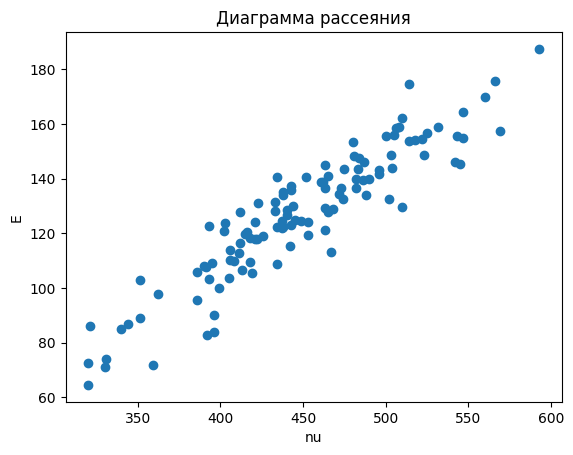

In [43]:
plt.scatter(X, Y)
plt.xlabel('nu')
plt.ylabel('E')
plt.title('Диаграмма рассеяния')
plt.show()

Визуально наблюдается зависимость между переменными.

## 2. Выборочные прямые среднеквадратической регрессии

Используем формулы линейных регрессий:

$$
y_x = \bar y + r_{xy}\frac{s_y}{s_x}(x-\bar x),
$$

$$
x_y = \bar x + r_{xy}\frac{s_x}{s_y}(y-\bar y).
$$

После приведения к виду прямой получаем:

$$
y = a_{yx} + b_{yx}x,
\qquad
x = a_{xy} + b_{xy}y.
$$

Уравнение регрессии Y на X: y = -44.1958 + 0.3818*x
Уравнение регрессии X на Y: x = 164.7221 + 2.2339*y


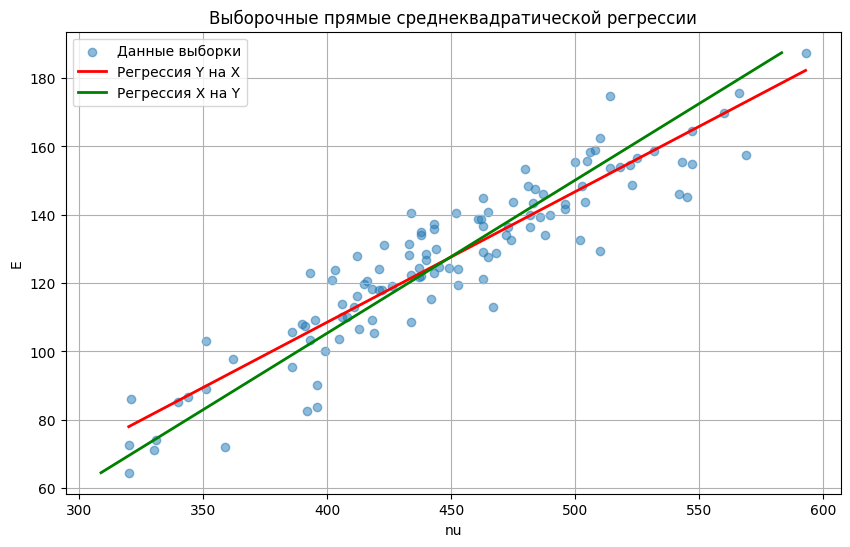

In [44]:
b1 = np.cov(X, Y, bias=True)[0, 1] / np.var(X)
b0 = Y.mean() - b1 * X.mean()

a1 = np.cov(X, Y, bias=True)[0, 1] / np.var(Y)
a0 = X.mean() - a1 * Y.mean()

print(f"Уравнение регрессии Y на X: y = {b0:.4f} + {b1:.4f}*x")
print(f"Уравнение регрессии X на Y: x = {a0:.4f} + {a1:.4f}*y")

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.5, label='Данные выборки')

x_range = np.linspace(X.min(), X.max(), 100)
y_pred = b0 + b1 * x_range
plt.plot(x_range, y_pred, color='red', linewidth=2, label='Регрессия Y на X')

y_range = np.linspace(Y.min(), Y.max(), 100)
x_pred = a0 + a1 * y_range
plt.plot(x_pred, y_range, color='green', linewidth=2, label='Регрессия X на Y')

plt.xlabel('nu')
plt.ylabel('E')
plt.title('Выборочные прямые среднеквадратической регрессии')
plt.legend()
plt.grid(True)
plt.show()

- Прямые пересекаются в точке средних значений $(\bar{x}, \bar{y})$.
- Малый угол между прямыми подтверждает высокую тесноту линейной связи.

## 3. Корелляционная таблица и нахождение выборочного корелляционного отношения

In [45]:
k = 14
x_bins = np.linspace(X.min(), X.max(), k + 1)
y_bins = np.linspace(Y.min(), Y.max(), k + 1)

work = df.copy()
work['x_interval'] = pd.cut(work['nu'], bins=x_bins, include_lowest=True)
work['y_interval'] = pd.cut(work['E'], bins=y_bins, include_lowest=True)

corr_table = pd.crosstab(work['y_interval'], work['x_interval'], margins=True)

def calculate_eta_grouped(x, y, x_bins):
    df_temp = pd.DataFrame({'x': x, 'y': y})
    df_temp['bin'] = pd.cut(df_temp['x'], bins=x_bins, include_lowest=True)
    grouped = df_temp.groupby('bin', observed=True)['y']
    y_group_means = grouped.mean()
    n_j = grouped.count()
    y_overall_mean = y.mean()
    intergroup_var = (n_j * (y_group_means - y_overall_mean)**2).sum() / len(y)
    total_var = y.var(ddof=0)
    return np.sqrt(intergroup_var / total_var)

r_xy = np.corrcoef(X, Y)[0, 1]
eta_yx = calculate_eta_grouped(X, Y, x_bins)
eta_xy = calculate_eta_grouped(Y, X, y_bins)

print(f"Выборочный коэффициент корреляции r_xy: {r_xy:.4f}")
print(f"Корреляционное отношение eta_yx: {eta_yx:.4f}")
print(f"Корреляционное отношение eta_xy: {eta_xy:.4f}")

print('\nПроверка условий:')
print(f"eta_yx >= |r_xy|: {eta_yx >= abs(r_xy) - 1e-7}")
print(f"eta_xy >= |r_xy|: {eta_xy >= abs(r_xy) - 1e-7}")

display(corr_table)

Выборочный коэффициент корреляции r_xy: 0.9235
Корреляционное отношение eta_yx: 0.9338
Корреляционное отношение eta_xy: 0.9259

Проверка условий:
eta_yx >= |r_xy|: True
eta_xy >= |r_xy|: True


x_interval,"(319.999, 339.5]","(339.5, 359.0]","(359.0, 378.5]","(378.5, 398.0]","(398.0, 417.5]","(417.5, 437.0]","(437.0, 456.5]","(456.5, 476.0]","(476.0, 495.5]","(495.5, 515.0]","(515.0, 534.5]","(534.5, 554.0]","(554.0, 573.5]","(573.5, 593.0]",All
y_interval,,,,,,,,,,,,,,,
"(64.499, 73.279]",3,1,0,0,0,0,0,0,0,0,0,0,0,0,4
"(73.279, 82.057]",1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
"(82.057, 90.836]",1,3,0,3,0,0,0,0,0,0,0,0,0,0,7
"(90.836, 99.614]",0,0,1,1,0,0,0,0,0,0,0,0,0,0,2
"(99.614, 108.393]",0,1,0,4,3,1,0,0,0,0,0,0,0,0,9
"(108.393, 117.171]",0,0,0,1,5,2,1,1,0,0,0,0,0,0,10
"(117.171, 125.95]",0,0,0,1,4,8,6,1,0,0,0,0,0,0,20
"(125.95, 134.729]",0,0,0,0,1,3,4,5,1,2,0,0,0,0,16
"(134.729, 143.507]",0,0,0,0,0,1,4,5,5,2,0,0,0,0,17


Оба корреляционных отношения оказались не меньше модуля коэффициента корреляции. Это означает, что произвольная регрессионная зависимость описывает связь не хуже, чем только линейная форма. В рассматриваемой выборке линейная связь уже очень сильная, однако небольшая нелинейность всё же присутствует.


## 4. Параболическая корреляционная кривая

Построим корреляционную кривую вида

$$
y = \beta_0 + \beta_1 x + \beta_2 x^2.
$$

Коэффициенты найдём методом наименьших квадратов.

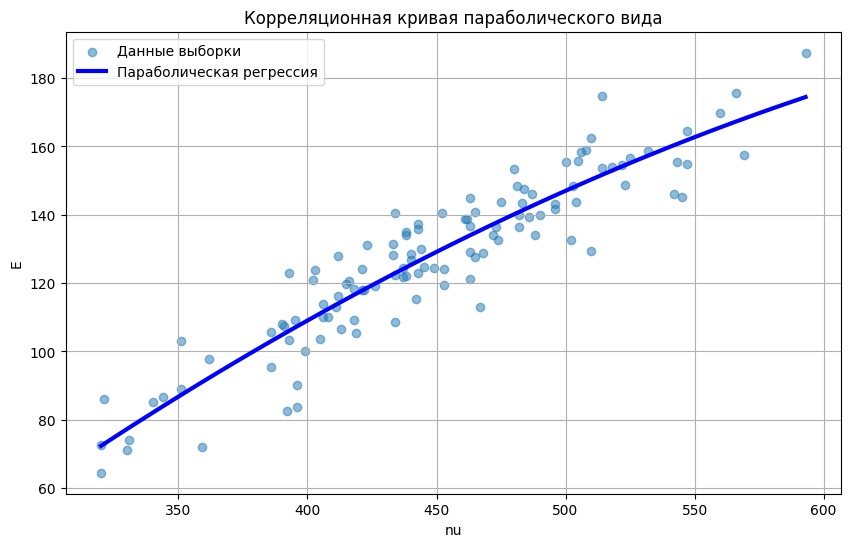

In [46]:
import numpy as np
import matplotlib.pyplot as plt

coeffs = np.polyfit(X, Y, 2)
b2, b1, b0 = coeffs

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.5, label='Данные выборки')

x_sort = np.linspace(X.min(), X.max(), 100)
y_sort = np.polyval(coeffs, x_sort)

plt.plot(x_sort, y_sort, color='blue', linewidth=3, label='Параболическая регрессия')
plt.xlabel('nu')
plt.ylabel('E')
plt.title('Корреляционная кривая параболического вида')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

quad_pred = np.polyval(coeffs, X)

quad_metrics = pd.DataFrame({
    'Метрика': ['R^2', 'RMSE', 'MAE'],
    'Значение': [
        r2_score(Y, quad_pred),
        np.sqrt(mean_squared_error(Y, quad_pred)),
        mean_absolute_error(Y, quad_pred)
    ]
})
quad_metrics

,Метрика,Значение
0,R^2,0.859563
1,RMSE,9.055215
2,MAE,7.071230


Коэффициент при $x^2$ получился малым по модулю, поэтому кривая лишь слегка отклоняется от прямой. Тем не менее параболическая модель немного лучше учитывает форму облака точек и даёт более точное приближение, чем чисто линейная зависимость.

## 5. Корреляционная кривая по варианту 31

Для варианта 31 используется **степенная функция**

$$
y = \beta_0 x^{\beta_1}.
$$

Линеаризуем её:

$$
\ln y = \ln \beta_0 + \beta_1 \ln x.
$$

После этого параметры можно определить методом наименьших квадратов для преобразованных данных.


Степенная модель:
y = 0.020741 * x^1.426896


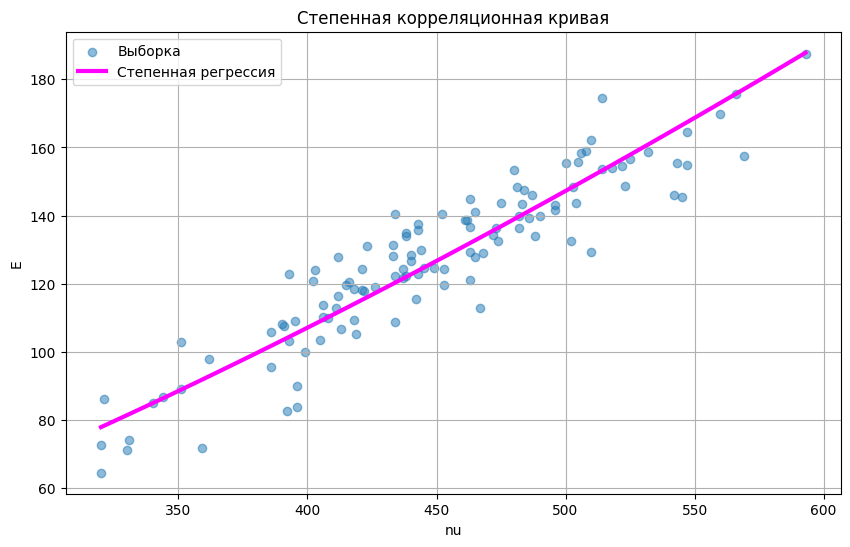

In [48]:
beta1_power, ln_beta0_power = np.polyfit(np.log(X), np.log(Y), 1)
beta0_power = np.exp(ln_beta0_power)

print(f"Степенная модель:")
print(f"y = {beta0_power:.6f} * x^{beta1_power:.6f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.5, label='Выборка')

x_space = np.linspace(X.min(), X.max(), 100)
y_power_curve = beta0_power * x_space**beta1_power

plt.plot(x_space, y_power_curve, color='magenta', linewidth=3, label='Степенная регрессия')
plt.xlabel('nu')
plt.ylabel('E')
plt.title('Степенная корреляционная кривая')
plt.grid(True)
plt.legend()
plt.show()

In [49]:
power_pred = beta0_power * X**beta1_power

power_metrics = pd.DataFrame({
    'Метрика': ['R^2', 'RMSE', 'MAE'],
    'Значение': [
        r2_score(Y, power_pred),
        np.sqrt(mean_squared_error(Y, power_pred)),
        mean_absolute_error(Y, power_pred)
    ]
})
power_metrics

,Метрика,Значение
0,R^2,0.843740
1,RMSE,9.551726
2,MAE,7.399833


Степенная функция отражает общий рост $E$ при увеличении $\nu$, однако для данной выборки она описывает зависимость чуть грубее, чем параболическая модель. Это говорит о том, что связь между признаками действительно монотонная и сильная, но её форма ближе к почти линейной с небольшим искривлением, чем к чисто степенному закону.

## Вывод

1. На диаграмме рассеяния выявлена сильная положительная зависимость между объёмным весом древесины и модулем упругости.
2. Выборочные прямые среднеквадратической регрессии имеют возрастающий вид и пересекаются в точке средних значений признаков.
3. Корреляционные отношения оказались не меньше модуля коэффициента корреляции, следовательно, нелинейное описание связи допустимо и теоретически оправдано.
4. Параболическая модель дала более точное приближение по сравнению с линейной, но выигрыш оказался небольшим, так как коэффициент при квадрате мал.
5. Построена степенная корреляционная кривая. Она корректно передаёт тенденцию роста, однако уступает параболической модели по точности.
6. Для данной выборки связь между признаками можно охарактеризовать как сильную, положительную и близкую к линейной, но с умеренным нелинейным эффектом.